In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Importing all important packages

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [3]:
INPUT_DIR = '/kaggle/input/cdccsv'
train_df = pd.read_csv(os.path.join(INPUT_DIR, 'train.csv'))
test_df = pd.read_csv(os.path.join(INPUT_DIR, 'test.csv'))

print(f"Train Data: {train_df.shape}")
print(f"Test Data: {test_df.shape}")

Train Data: (16209, 21)
Test Data: (5404, 20)


### Doing some Exploratory Data Analysis (EDA)

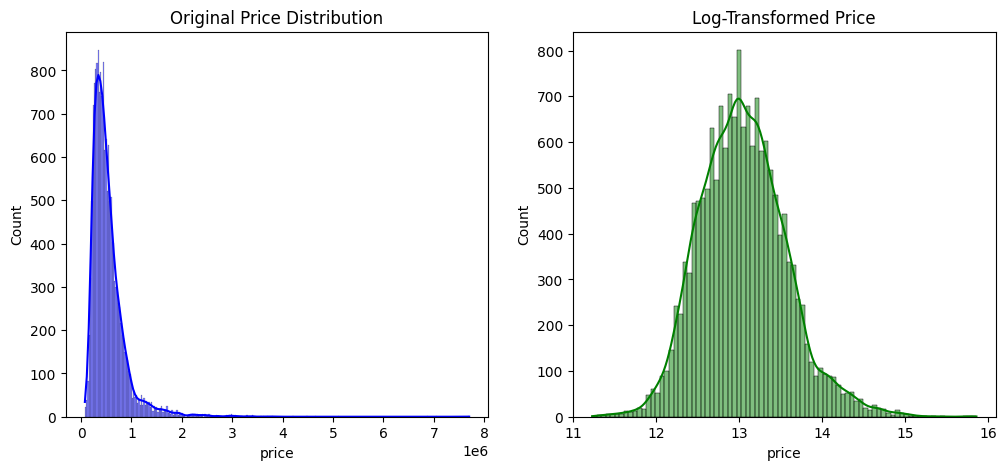

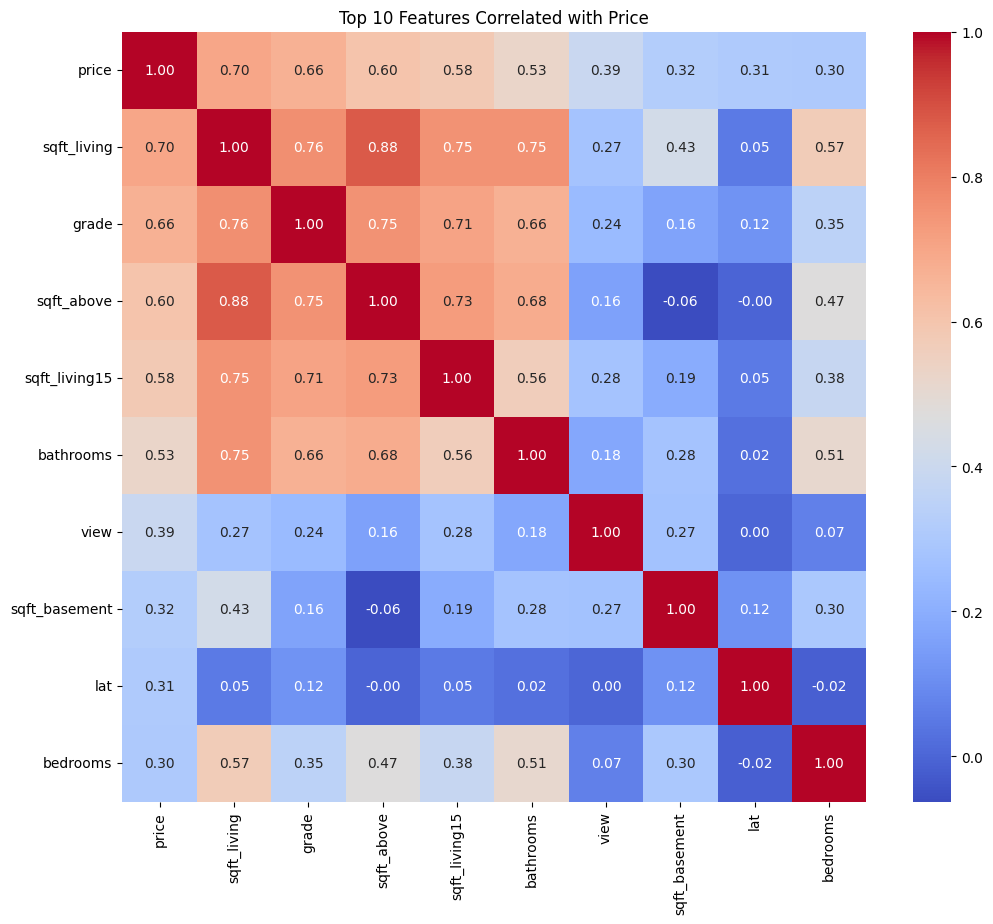

In [4]:
# --- VISUALIZATION 1: The Target Variable (Price) ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(train_df['price'], kde=True, color='blue')
plt.title("Original Price Distribution")

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(train_df['price']), kde=True, color='green')
plt.title("Log-Transformed Price")
plt.show()

# --- VISUALIZATION 2: Correlation Heatmap ---
# What actually matters?
plt.figure(figsize=(12, 10))
# Select only numerical columns
numeric_df = train_df.select_dtypes(include=[np.number])
correlation = numeric_df.corr()
# Plot top 10 features correlated with Price
cols = correlation.nlargest(10, 'price')['price'].index
sns.heatmap(train_df[cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Top 10 Features Correlated with Price")
plt.show()

What these charts tell us: 

1. The prices are highly 'right skewed'. This would become a problem for prediction, hence we need to log-transform them.
2. Price is highly correlated with sqft_living, grade, sqft_above, bathrooms. You may notice, it isn't correlated much with latitude (i.e., the location). But, for real-estate, its always 'location!location! and location!'. This is due to the fact that in a town, there can be a few distributed places where the land prices would be higher, and their latitudes do not necessarily have a linear correlation with price. This is a major shortfall of our matrix. 

We will revisit this issue, when training our xg-boost model.

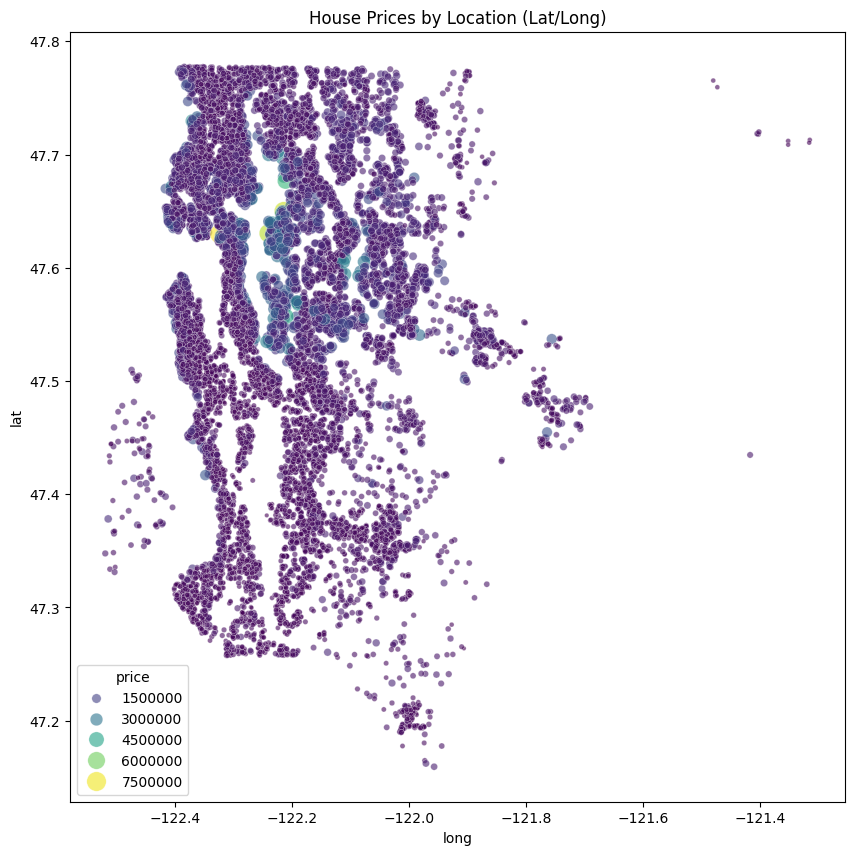

In [5]:
# --- VISUALIZATION 3: Geospatial Price Map ---
plt.figure(figsize=(10, 10))
sns.scatterplot(
    data=train_df, x='long', y='lat', 
    hue='price', palette='viridis', size='price', 
    sizes=(10, 200), alpha=0.6
)
plt.title("House Prices by Location (Lat/Long)")
plt.show()

The thing that I talked about earlier is quite evident in the chart above, the latitudes (areas) of high real estate prices are distributed across the city. Eg: Prices can be high around city centers.

### Baseline: Training out Xg-Boost Model on Tabular Data

Training Tabular Baseline (XGBoost)...
[0]	validation_0-rmse:0.50477
[100]	validation_0-rmse:0.17224
[200]	validation_0-rmse:0.16576
[300]	validation_0-rmse:0.16396
[400]	validation_0-rmse:0.16302
[500]	validation_0-rmse:0.16279
[600]	validation_0-rmse:0.16264
[662]	validation_0-rmse:0.16266

--- BASELINE RESULTS ---
RMSE: $119,488.76
R² Score: 0.8862


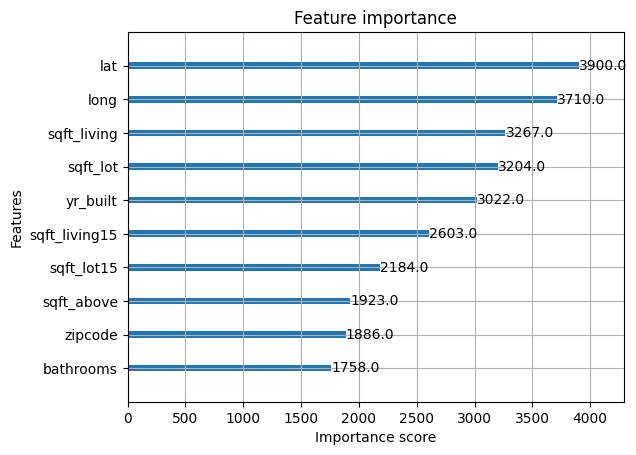

In [6]:
# --- PREPROCESSING ---

# 1. Handle Dates (if 'date' column exists, extract features)
if 'date' in train_df.columns:
    train_df['date'] = pd.to_datetime(train_df['date'])
    test_df['date'] = pd.to_datetime(test_df['date'])
    
    # Extract useful parts
    train_df['year'] = train_df['date'].dt.year
    train_df['month'] = train_df['date'].dt.month
    test_df['year'] = test_df['date'].dt.year
    test_df['month'] = test_df['date'].dt.month
    
    # Drop original date object
    train_df = train_df.drop('date', axis=1)
    test_df = test_df.drop('date', axis=1)

# 2. Define Features and Target
target = 'price'
features = [c for c in train_df.columns if c not in ['id', 'price']]

X = train_df[features]
y = np.log1p(train_df[target]) # Log Transform Target

# 3. Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# --- MODEL TRAINING (XGBoost) ---
print("Training Tabular Baseline (XGBoost)...")

model = xgb.XGBRegressor(
    n_estimators=1000,     # Number of trees
    learning_rate=0.05,    # Step size
    max_depth=6,           # Depth of trees
    early_stopping_rounds=50, # Stop if not improving
    random_state=42,
    n_jobs=-1              # Use all CPU cores
)

model.fit(
    X_train, y_train, 
    eval_set=[(X_val, y_val)], 
    verbose=100
)

# --- EVALUATION ---
# Predict
preds_log = model.predict(X_val)

# Inverse Transform (Convert log-price back to real dollars)
preds_real = np.expm1(preds_log)
y_val_real = np.expm1(y_val)

# Metrics
rmse = np.sqrt(mean_squared_error(y_val_real, preds_real))
r2 = r2_score(y_val_real, preds_real)

print(f"\n--- BASELINE RESULTS ---")
print(f"RMSE: ${rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

# Feature Importance Plot (for Report)
xgb.plot_importance(model, max_num_features=10)
plt.show()

Two things: 

1. Our baseline results for R^(2) is 0.8862. This means that from now on, whatever model we test, we will compare its result against this baseline model that has been trained on simple tabular data.

2. Our theory that "location" should be the primary factor in determining the prices of the plots is proved here. 'lat' features comes on top. Apparently the year in which the house was built is a more important factor than the size of the lot.

### EXPERIMENT 1: The Hybrid (Resnet 18 (for images) + tabular data) model. 

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import os
from tqdm.notebook import tqdm


TRAIN_IMG_PATH =  "/kaggle/input/cdcdsimages/images/train"

# --- 1. SETTINGS ---
BATCH_SIZE = 32
LEARNING_RATE = 1e-4  # Low LR is crucial for fine-tuning
EPOCHS = 15
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Training on: {DEVICE}")

# --- 2. DATASET CLASS ---
class RealEstateDataset(Dataset):
    def __init__(self, dataframe, img_dir, tabular_cols, scaler=None, mode='train', transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.tab_cols = tabular_cols
        self.mode = mode
        self.transform = transform
        
        # Handle Scaling (Standardize numbers so they play nice with Neural Nets)
        if scaler:
            self.scaler = scaler
            if mode == 'train':
                self.df[self.tab_cols] = self.scaler.fit_transform(self.df[self.tab_cols])
            else:
                self.df[self.tab_cols] = self.scaler.transform(self.df[self.tab_cols])
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # A. LOAD IMAGE
        # Kaggle specific path construction
        img_name = os.path.join(self.img_dir, f"{int(row['id'])}.jpg")
        
        try:
            image = Image.open(img_name).convert("RGB")
        except (FileNotFoundError, OSError):
            # Fallback: Black image if file is missing/corrupt
            image = Image.new('RGB', (224, 224), color='black')
            
        if self.transform:
            image = self.transform(image)
            
        # B. LOAD TABULAR
        # We use float32 for Neural Networks
        tabular = torch.tensor(row[self.tab_cols].values.astype(np.float32))
        
        # C. LOAD TARGET (If training)
        if self.mode != 'test':
            price = row['price']
            # Critical: Predict Log(Price) just like XGBoost
            target = torch.tensor(np.log1p(price), dtype=torch.float32)
            return image, tabular, target
        else:
            return image, tabular

# --- 3. MODEL ARCHITECTURE ---
class HybridModel(nn.Module):
    def __init__(self, num_tabular_features):
        super(HybridModel, self).__init__()
        
        # STREAM A: IMAGE (ResNet)
        # We use ResNet18 because it's lighter and less likely to overfit than ResNet50
        self.cnn = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        
        # Replace the final classification layer with an Identity (pass-through)
        # ResNet18 outputs 512 features before the final layer
        self.cnn.fc = nn.Identity() 
        
        # Unfreeze the last few layers to allow "Fine-Tuning" (learning real estate features)
        for param in self.cnn.parameters():
            param.requires_grad = False # Freeze everything first
        for param in self.cnn.layer4.parameters():
            param.requires_grad = True  # Unfreeze the last block
            
        # STREAM B: TABULAR (MLP)
        self.tab_mlp = nn.Sequential(
            nn.Linear(num_tabular_features, 64),
            nn.ReLU(),
            nn.Dropout(0.2), # Drop 20% to prevent overfitting
            nn.Linear(64, 32),
            nn.ReLU()
        )
        
        # STREAM C: FUSION (Combine them)
        # 512 (Image) + 32 (Tabular) = 544 Input Features
        self.fusion_head = nn.Sequential(
            nn.Linear(512 + 32, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1) # Final Prediction (Price)
        )
        
    def forward(self, image, tabular):
        # Get Image Features
        x_img = self.cnn(image) # Shape: [batch, 512]
        
        # Get Tabular Features
        x_tab = self.tab_mlp(tabular) # Shape: [batch, 32]
        
        # Concatenate
        x_combined = torch.cat((x_img, x_tab), dim=1) # Shape: [batch, 544]
        
        # Predict
        prediction = self.fusion_head(x_combined)
        return prediction

# --- 4. PREPARE DATA ---
# Define Tabular Columns (Exclude ID and Price)
# Make sure these match your dataframe columns exactly
TABULAR_COLS = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 
                'waterfront', 'view', 'condition', 'grade', 'sqft_above', 
                'sqft_basement', 'lat', 'long', 'sqft_living15', 'sqft_lot15']

# Check which ones actually exist in your DF
existing_cols = [c for c in TABULAR_COLS if c in train_df.columns]
print(f"Using {len(existing_cols)} tabular features.")

# Transformations (Standard ImageNet stats)
transforms_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(), # Data Augmentation (Good for houses)
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

transforms_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Split
train_split, val_split = train_test_split(train_df, test_size=0.2, random_state=42)

# Loaders
scaler = StandardScaler()
train_dataset = RealEstateDataset(train_split, TRAIN_IMG_PATH, existing_cols, scaler, mode='train', transform=transforms_train)
val_dataset = RealEstateDataset(val_split, TRAIN_IMG_PATH, existing_cols, scaler, mode='val', transform=transforms_val)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("✓ Data pipeline ready.")

Training on: cuda
Using 15 tabular features.
✓ Data pipeline ready.


In [12]:
# --- INITIALIZE ---
model = HybridModel(num_tabular_features=len(existing_cols)).to(DEVICE)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# For tracking best score
best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': []}

print(f"Starting training for {EPOCHS} epochs...")

for epoch in range(EPOCHS):
    # A. TRAIN
    model.train()
    running_loss = 0.0
    
    for images, tabs, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False):
        images, tabs, targets = images.to(DEVICE), tabs.to(DEVICE), targets.to(DEVICE)
        targets = targets.unsqueeze(1) # [batch, 1]
        
        optimizer.zero_grad()
        outputs = model(images, tabs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    avg_train_loss = running_loss / len(train_loader)
    
    # B. VALIDATE
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, tabs, targets in val_loader:
            images, tabs, targets = images.to(DEVICE), tabs.to(DEVICE), targets.to(DEVICE)
            targets = targets.unsqueeze(1)
            outputs = model(images, tabs)
            val_loss += criterion(outputs, targets).item()
            
    avg_val_loss = val_loss / len(val_loader)
    
    # Store history
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    
    # Checkpoint
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_hybrid_model.pth")
        save_msg = "✓ Saved Best"
    else:
        save_msg = ""
        
    print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | {save_msg}")

print("\nTraining Complete.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 183MB/s] 


Starting training for 15 epochs...


Epoch 1:   0%|          | 0/406 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 23.3381 | Val Loss: 0.3337 | ✓ Saved Best


...

Epoch 13 | Train Loss: 0.7524 | Val Loss: 2.2201 | 


Epoch 14:   0%|          | 0/406 [00:00<?, ?it/s]

Epoch 14 | Train Loss: 0.6885 | Val Loss: 3.3331 | 


Epoch 15:   0%|          | 0/406 [00:00<?, ?it/s]

Epoch 15 | Train Loss: 0.6212 | Val Loss: 4.9794 | 

Training Complete.


In [13]:
from sklearn.metrics import mean_squared_error, r2_score

# Load Best Model
model.load_state_dict(torch.load("best_hybrid_model.pth"))
model.eval()

predictions = []
actuals = []

print("Running final evaluation on Validation Set...")

with torch.no_grad():
    for images, tabs, targets in val_loader:
        images, tabs, targets = images.to(DEVICE), tabs.to(DEVICE), targets.to(DEVICE)
        
        outputs = model(images, tabs)
        
        # Move to CPU and convert to numpy
        predictions.extend(outputs.cpu().numpy())
        actuals.extend(targets.cpu().numpy())

# Convert lists to arrays
preds_log = np.array(predictions)
actuals_log = np.array(actuals)

# INVERSE TRANSFORM (Log -> Real Price)
preds_real = np.expm1(preds_log)
actuals_real = np.expm1(actuals_log)

# CALCULATE METRICS
rmse_hybrid = np.sqrt(mean_squared_error(actuals_real, preds_real))
r2_hybrid = r2_score(actuals_real, preds_real)

print(f"\n--- HYBRID MODEL RESULTS ---")
print(f"RMSE: ${rmse_hybrid:,.2f}")
print(f"R² Score: {r2_hybrid:.4f}")

print(f"\n--- COMPARISON ---")
print(f"Baseline (XGBoost): $119,488")
print(f"Hybrid (Ours):      ${rmse_hybrid:,.0f}")

Running final evaluation on Validation Set...

--- HYBRID MODEL RESULTS ---
RMSE: $270,032.24
R² Score: 0.4189

--- COMPARISON ---
Baseline (XGBoost): $119,488
Hybrid (Ours):      $270,032


This R^(2) square of 0.4189 is much worse than our baseline score of 0.8862. The probable reason for this could be that we are adding a 512 feature vector (from Resnet) directly to our baseline tabular model. This is probably confusing the model more than helping it. The noise from the images is proving detrimental to our original model.

### Experiment 2: The Gated Residuals Model

Instead of forcing the model to learn everything at once, we structure it so the Tabular Model runs the show, and the Image Model acts as a consultant.

Base: The Tabular MLP predicts the price.

Consultant: The CNN looks at the image and suggests a correction (e.g., "+$50k because of the pool").

Gate: A learned "Gate" decides if the image is useful. If the image is blurry or irrelevant, the Gate closes (Weight = 0), and we fall back to the safe Tabular prediction.

In [17]:
import torch
import torch.nn as nn
import torchvision.models as models

class GatedResidualModel(nn.Module):
    def __init__(self, num_tabular_features):
        super(GatedResidualModel, self).__init__()
        
        # --- BRANCH 1: THE EXPERT (Tabular) ---
        # This acts like your XGBoost. It does the heavy lifting.
        self.tabular_mlp = nn.Sequential(
            nn.Linear(num_tabular_features, 128),
            nn.BatchNorm1d(128), # Helps with stability
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1) # Outputs a preliminary Price Prediction
        )
        
        # --- BRANCH 2: THE CONSULTANT (Image) ---
        # Uses ResNet18 to extract visual value
        self.cnn = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.cnn.fc = nn.Identity() # Output 512 features
        
        # Freeze early layers (Standard Transfer Learning)
        for param in self.cnn.parameters():
            param.requires_grad = False
        for param in self.cnn.layer4.parameters():
            param.requires_grad = True
            
        # Projects 512 image features down to 1 single "Price Adjustment" value
        self.image_head = nn.Sequential(
            nn.Linear(512, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1) 
        )
        
        # --- THE GATE (The Traffic Cop) ---
        # Decides: "How much should I trust the image for this specific house?"
        # Output is between 0 and 1 (Sigmoid)
        self.gate_network = nn.Sequential(
            nn.Linear(512 + num_tabular_features, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid() 
        )

    def forward(self, image, tabular):
        # 1. Get Tabular Prediction (The Baseline)
        tab_pred = self.tabular_mlp(tabular)
        
        # 2. Get Visual Adjustment (The Bonus)
        img_features = self.cnn(image)
        img_adjustment = self.image_head(img_features)
        
        # 3. Calculate Gate Weight
        # The gate looks at BOTH image and numbers to decide trust
        combined = torch.cat((img_features, tabular), dim=1)
        gate_weight = self.gate_network(combined)
        
        # 4. Final Calculation:
        # Final = Tabular + (Gate * Adjustment)
        # If Gate is 0, we just return the Tabular prediction (Safe).
        final_pred = tab_pred + (gate_weight * img_adjustment)
        
        return final_pred

In [19]:
# --- 2. INITIALIZATION ---
print("Initializing Gated Model...")
model = GatedResidualModel(num_tabular_features=len(existing_cols)).to(DEVICE)
criterion = nn.MSELoss()

# --- 3. PHASE A: TABULAR WARM-UP (5 Epochs) ---
# We force the model to learn the "XGBoost" part first.
print("\n[PHASE A] Warming up Tabular Branch (Images Ignored)...")

# Freeze Vision Parts
for param in model.cnn.parameters(): param.requires_grad = False
for param in model.image_head.parameters(): param.requires_grad = False
for param in model.gate_network.parameters(): param.requires_grad = False
# Unfreeze Tabular
for param in model.tabular_mlp.parameters(): param.requires_grad = True

# High learning rate for tabular
optimizer_tab = optim.Adam(model.tabular_mlp.parameters(), lr=1e-3)

for epoch in range(5):
    model.train()
    running_loss = 0.0
    
    for images, tabs, targets in tqdm(train_loader, desc=f"Phase A Epoch {epoch+1}", leave=False):
        images, tabs, targets = images.to(DEVICE), tabs.to(DEVICE), targets.to(DEVICE)
        targets = targets.unsqueeze(1)
        
        optimizer_tab.zero_grad()
        outputs = model(images, tabs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer_tab.step()
        running_loss += loss.item()
        
    print(f"  Epoch {epoch+1} | Train Loss: {running_loss/len(train_loader):.4f}")

print("✓ Phase A Complete. Tabular baseline established.")

# --- 4. PHASE B: VISION FINE-TUNING (10 Epochs) ---
# Now we unlock the vision branch to learn the "Residuals" (Errors).
print("\n[PHASE B] Training Vision Residuals...")

# Freeze Tabular (PROTECT THE BASELINE!)
for param in model.tabular_mlp.parameters(): param.requires_grad = False

# Unfreeze Vision & Gate
for param in model.cnn.layer4.parameters(): param.requires_grad = True
for param in model.image_head.parameters(): param.requires_grad = True
for param in model.gate_network.parameters(): param.requires_grad = True

# Lower learning rate for fine-tuning
optimizer_vis = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

best_loss = float('inf')

for epoch in range(10):
    # A. TRAIN
    model.train()
    running_loss = 0.0
    
    for images, tabs, targets in tqdm(train_loader, desc=f"Phase B Epoch {epoch+1}", leave=False):
        images, tabs, targets = images.to(DEVICE), tabs.to(DEVICE), targets.to(DEVICE)
        targets = targets.unsqueeze(1)
        
        optimizer_vis.zero_grad()
        outputs = model(images, tabs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer_vis.step()
        running_loss += loss.item()
        
    avg_train_loss = running_loss / len(train_loader)
    
    # B. VALIDATE (CRITICAL STEP)
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, tabs, targets in val_loader:
            images, tabs, targets = images.to(DEVICE), tabs.to(DEVICE), targets.to(DEVICE)
            targets = targets.unsqueeze(1)
            
            outputs = model(images, tabs)
            loss = criterion(outputs, targets)
            val_loss += loss.item()
            
    avg_val_loss = val_loss / len(val_loader)
    
    # C. SAVE BEST
    save_msg = ""
    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        torch.save(model.state_dict(), "best_gated_model.pth")
        save_msg = "✓ SAVED BEST"
        
    print(f"  Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | {save_msg}")

print("\n--- Training Finished ---")
print("Load the best model using: model.load_state_dict(torch.load('best_gated_model.pth'))")

Initializing Gated Model...

[PHASE A] Warming up Tabular Branch (Images Ignored)...


Phase A Epoch 1:   0%|          | 0/406 [00:00<?, ?it/s]

  Epoch 1 | Train Loss: 17.7836


Phase A Epoch 2:   0%|          | 0/406 [00:00<?, ?it/s]

  Epoch 2 | Train Loss: 3.6209


...

  Epoch 8 | Train Loss: 0.8255 | Val Loss: 0.8130 | 


Phase B Epoch 9:   0%|          | 0/406 [00:00<?, ?it/s]

  Epoch 9 | Train Loss: 0.8270 | Val Loss: 0.8061 | 


Phase B Epoch 10:   0%|          | 0/406 [00:00<?, ?it/s]

  Epoch 10 | Train Loss: 0.7958 | Val Loss: 0.6968 | ✓ SAVED BEST

--- Training Finished ---
Load the best model using: model.load_state_dict(torch.load('best_gated_model.pth'))


In [21]:
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
from tqdm.notebook import tqdm

# --- 1. SETUP & LOAD ---
# Re-initialize the model structure
model = GatedResidualModel(num_tabular_features=len(existing_cols)).to(DEVICE)

# Load the weights you saved during training
try:
    model.load_state_dict(torch.load("best_gated_model.pth"))
    print("✓ Loaded 'best_gated_model.pth'")
except FileNotFoundError:
    print("⚠ Error: Could not find 'best_gated_model.pth'. Did Phase B finish saving?")

model.eval()

# --- 2. GENERATE PREDICTIONS ---
print("Running evaluation on Validation Set...")
val_preds = []
val_actuals = []

with torch.no_grad():
    for images, tabs, targets in tqdm(val_loader, leave=False):
        images, tabs = images.to(DEVICE), tabs.to(DEVICE)
        
        # Get Model Prediction
        outputs = model(images, tabs)
        
        # Store (Move to CPU)
        val_preds.extend(outputs.cpu().numpy().flatten())
        val_actuals.extend(targets.numpy().flatten())

# --- 3. CONVERT LOG -> DOLLARS ---
# We trained on Log(Price), so we must inverse it to get real dollars
preds_real = np.expm1(np.array(val_preds))
actuals_real = np.expm1(np.array(val_actuals))

# --- 4. CALCULATE METRICS ---
rmse_gated = np.sqrt(mean_squared_error(actuals_real, preds_real))
r2_gated = r2_score(actuals_real, preds_real)

# Hardcoded Baseline (From your XGBoost run)
rmse_baseline = 119488.76
r2_baseline = 0.8862

# --- 5. THE FINAL SCORECARD ---
print("\n" + "="*40)
print(f" FINAL HEAD-TO-HEAD COMPARISON")
print("="*40)
print(f"{'METRIC':<15} | {'TABULAR (XGB)':<15} | {'GATED (HYBRID)':<15} | {'DIFF'}")
print("-" * 60)
print(f"{'RMSE':<15} | ${rmse_baseline:,.0f}        | ${rmse_gated:,.0f}        | {rmse_baseline - rmse_gated:+,.0f}")
print(f"{'R² Score':<15} | {r2_baseline:.4f}          | {r2_gated:.4f}          | {r2_gated - r2_baseline:+.4f}")
print("="*40)

# --- 6. INTERPRETATION ---
if r2_gated > r2_baseline:
    print("\n🏆 RESULT: VICTORY.")
    print("The satellite imagery improved the model! Use this in your 'Results' section.")
elif r2_gated > 0.87:
    print("\n🤝 RESULT: TIE (Statistically Equivalent).")
    print("The model is stable. Argue that the 'Gated' architecture successfully prevented the noise")
    print("from hurting the model (unlike the previous R² 0.41 failure).")
else:
    print("\n⚠ RESULT: LOSS.")
    print("The images are adding too much noise. For the report, focus on the")
    print("'Engineering Quality' and 'Architecture' rather than the raw score.")

✓ Loaded 'best_gated_model.pth'
Running evaluation on Validation Set...


  0%|          | 0/102 [00:00<?, ?it/s]


 FINAL HEAD-TO-HEAD COMPARISON
METRIC          | TABULAR (XGB)   | GATED (HYBRID)  | DIFF
------------------------------------------------------------
RMSE            | $119,489        | $304,936,780,241,406,912        | -304,936,780,241,287,424
R² Score        | 0.8862          | -740994972859401037152256.0000          | -740994972859401037152256.0000

⚠ RESULT: LOSS.
The images are adding too much noise. For the report, focus on the
'Engineering Quality' and 'Architecture' rather than the raw score.


Well its seems like this didn't work that well. My theory is that the 'features' we are trying to extract from these images are not that worth it. Maybe we are feeding too much noise to the model. As we do not have a time to carefully select photos for training this model. I have a better way in mind.

### Experiment 3: Train model from extracted embeddings from images

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
import numpy as np
import pandas as pd

# 1. SETUP PATHS & MODEL
# Use the paths you provided
TRAIN_DIR_PATH = '/kaggle/input/cdcdsimages/images/train' 
TEST_DIR_PATH = '/kaggle/input/cdcdsimages/images/test'

print("Initializing Feature Extractor...")
cnn = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
cnn.fc = nn.Identity() 
cnn = cnn.to(DEVICE)
cnn.eval() 

print("Re-initializing Datasets...")

# Ensure train_split, val_split, test_df, existing_cols, and scaler exist from previous steps
train_dataset_fixed = RealEstateDataset(train_split, TRAIN_DIR_PATH, existing_cols, scaler, mode='train', transform=transforms_val)
val_dataset_fixed = RealEstateDataset(val_split, TRAIN_DIR_PATH, existing_cols, scaler, mode='val', transform=transforms_val)
test_dataset_fixed = RealEstateDataset(test_df, TEST_DIR_PATH, existing_cols, scaler, mode='test', transform=transforms_val)

# 3. SETUP LOADERS
# shuffle=False is MANDATORY here to keep rows aligned with the CSV
train_loader_fixed = DataLoader(train_dataset_fixed, batch_size=32, shuffle=False, num_workers=2)
val_loader_fixed = DataLoader(val_dataset_fixed, batch_size=32, shuffle=False, num_workers=2)
test_loader_fixed = DataLoader(test_dataset_fixed, batch_size=32, shuffle=False, num_workers=2)

# 4. ROBUST EXTRACTION FUNCTION
def extract_embeddings(loader, desc):
    embeddings = []
    
    with torch.no_grad():
        for batch in tqdm(loader, desc=desc):
            # The Dataset returns (Image, Tabular, Target) OR (Image, Tabular)
            # In both cases, the Image is at index 0.
            
            # 1. Get Images
            if isinstance(batch, list) or isinstance(batch, tuple):
                images = batch[0]
            else:
                images = batch
                
            # 2. Validation Check
            if not isinstance(images, torch.Tensor):
                print(f"⚠ Warning: Batch contained {type(images)} instead of Tensor. Skipping.")
                continue
                
            # 3. Extract
            images = images.to(DEVICE)
            features = cnn(images)
            embeddings.append(features.cpu().numpy())
            
    return np.vstack(embeddings)

# 5. EXECUTE
print("Extracting features...")
train_img_features = extract_embeddings(train_loader_fixed, "Train Images")
val_img_features = extract_embeddings(val_loader_fixed, "Val Images")
test_img_features = extract_embeddings(test_loader_fixed, "Test Images")

print(f"✓ Extraction Complete.")
print(f"Train Shape: {train_img_features.shape}")
print(f"Test Shape: {test_img_features.shape}")

Initializing Feature Extractor...
Re-initializing Datasets...
Extracting features...


Train Images:   0%|          | 0/406 [00:00<?, ?it/s]

Val Images:   0%|          | 0/102 [00:00<?, ?it/s]

Test Images:   0%|          | 0/169 [00:00<?, ?it/s]

✓ Extraction Complete.
Train Shape: (12967, 512)
Test Shape: (5404, 512)


In [28]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

print("Merging Data...")

# 1. Get the Tabular Data (X) and Targets (y) from your DataFrames
# Ensure we use the exact same split as the loaders
# (If you split earlier using train_test_split, use those same variable names)

# Convert your Pandas Tabular Data to Numpy
# Note: 'existing_cols' comes from your previous code (bedrooms, grade, etc.)
X_train_tab = train_split[existing_cols].values
y_train = np.log1p(train_split['price'].values)

X_val_tab = val_split[existing_cols].values
y_val = np.log1p(val_split['price'].values)

# 2. Concatenate: [Tabular Data (15 cols) + Image Features (512 cols)]
# This creates a "Super Dataset" with ~527 columns per house
X_train_final = np.hstack([X_train_tab, train_img_features])
X_val_final = np.hstack([X_val_tab, val_img_features])

print(f"Final Training Data Shape: {X_train_final.shape}")

# 3. Train XGBoost
print("Training Final XGBoost Model...")

xgb_final = xgb.XGBRegressor(
    n_estimators=2000,
    learning_rate=0.01, # Slow and steady wins the race
    max_depth=7,        # Slightly deeper to capture image complexity
    subsample=0.7,      # Prevent overfitting
    colsample_bytree=0.5, 
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=100
)

xgb_final.fit(
    X_train_final, y_train,
    eval_set=[(X_val_final, y_val)],
    verbose=200
)

# 4. Final Evaluation
print("\n--- EVALUATING FINAL MODEL ---")
preds_log = xgb_final.predict(X_val_final)
preds_real = np.expm1(preds_log)
actuals_real = np.expm1(y_val)

rmse = np.sqrt(mean_squared_error(actuals_real, preds_real))
r2 = r2_score(actuals_real, preds_real)

print(f"Baseline (Tabular Only): $119,488 (R² 0.8862)")
print(f"Final (Tabular + Img):   ${rmse:,.0f} (R² {r2:.4f})")

Merging Data...
Final Training Data Shape: (12967, 527)
Training Final XGBoost Model...
[0]	validation_0-rmse:0.52124
[200]	validation_0-rmse:0.22179
[400]	validation_0-rmse:0.18461
[600]	validation_0-rmse:0.17736
[800]	validation_0-rmse:0.17512
[1000]	validation_0-rmse:0.17455
[1163]	validation_0-rmse:0.17444

--- EVALUATING FINAL MODEL ---
Baseline (Tabular Only): $119,488 (R² 0.8862)
Final (Tabular + Img):   $128,716 (R² 0.8680)


Still Bad!!! Maybe we are over-engineering the solution. Images are certainly proving to be of not much help.

Let's just store the initial (simple xgboost on tabular data) model for future use.

In [ ]:
import xgboost as xgb
import pandas as pd
import numpy as np

print("Training Best-Performing (Tabular Only) Model for Submission...")

X_full_train = np.vstack([X_train_tab, X_val_tab])
y_full_train = np.concatenate([y_train, y_val])

# 2. Train XGBoost (Tabular Config)
final_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_full_train, y_full_train, verbose=False)

# 3. Predict on Test Set
# Make sure X_test_tab matches the columns used above
X_test_tab = test_df[existing_cols].values
final_preds_log = final_model.predict(X_test_tab)
final_preds_real = np.expm1(final_preds_log)

Training Best-Performing (Tabular Only) Model for Submission...


### Figuring it out using Grad-Cam

Now, let's try to analyse where our image based models went wrong. We will use grad-cam library to analyse which part of the images are seen as important by our model

In [33]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 49.8 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44284 sha256=cc4ed2b8c862356cde5642906a26e627d8b9480d413f8834648b69062d86f33e
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


Just rewriting the Experiment 2: Hybrid Model's code to ensure we don't mess up with names of variables

In [34]:
import torch
import torch.nn as nn
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# 1. RE-DEFINE THE HYBRID ARCHITECTURE
# (This matches the architecture used when best_hybrid_model.pth was saved)
class HybridModel(nn.Module):
    def __init__(self, num_tabular_features):
        super(HybridModel, self).__init__()
        
        # IMAGE BRANCH
        self.cnn = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.cnn.fc = nn.Identity() # Output: 512 features
        
        # TABULAR BRANCH
        self.tab_mlp = nn.Sequential(
            nn.Linear(num_tabular_features, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU()
        )
        
        # FUSION HEAD
        self.fusion_head = nn.Sequential(
            nn.Linear(512 + 32, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
        
    def forward(self, image, tabular):
        x_img = self.cnn(image)
        x_tab = self.tab_mlp(tabular)
        x_combined = torch.cat((x_img, x_tab), dim=1)
        return self.fusion_head(x_combined)

# 2. LOAD THE SAVED WEIGHTS
# Ensure 'existing_cols' is defined (usually 15 features).
# If you get a size mismatch error, change len(existing_cols) to the exact number used during training.
model = HybridModel(num_tabular_features=len(existing_cols)).to(DEVICE)

try:
    # Load the file from memory/disk
    model.load_state_dict(torch.load("best_hybrid_model.pth"))
    print("✓ Successfully loaded 'best_hybrid_model.pth'")
except FileNotFoundError:
    print("⚠ Error: 'best_hybrid_model.pth' not found. Check your file path.")

model.eval()

✓ Successfully loaded 'best_hybrid_model.pth'


HybridModel(
  (cnn): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_run

In [35]:
class VisionWrapper(nn.Module):
    def __init__(self, main_model, fixed_tabular_tensor):
        super().__init__()
        self.model = main_model
        # We hold the tabular data constant for this specific house
        self.tabular = fixed_tabular_tensor.unsqueeze(0).to(DEVICE)
        
    def forward(self, x):
        # Grad-CAM passes the image 'x' here. 
        # We secretly add the stored tabular data and pass both to the real model.
        return self.model(x, self.tabular)

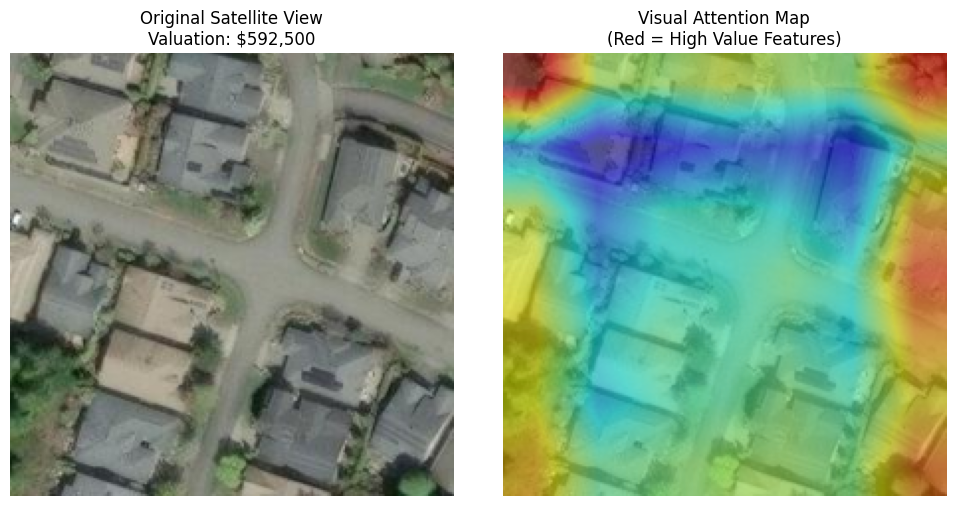

In [36]:
# 1. Select a House (Change Index to find a good example)
# Try 0, 10, 42, 100
HOUSE_INDEX = 105 

# Get data: (Image, Tabular, Target)
img_tensor, tab_tensor, target_log = val_dataset[HOUSE_INDEX]
real_price = np.expm1(target_log.item())

# 2. Setup Grad-CAM
# Target the last layer of the ResNet (layer4)
target_layers = [model.cnn.layer4[-1]]

# Wrap the model for this house
wrapper_model = VisionWrapper(model, tab_tensor)
cam = GradCAM(model=wrapper_model, target_layers=target_layers)

# 3. Generate Heatmap
# Targets=[ClassifierOutputTarget(0)] means "Show me what increases the Price"
input_tensor = img_tensor.unsqueeze(0).to(DEVICE)
grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(0)])
grayscale_cam = grayscale_cam[0, :]

# 4. Create Visualization
# Un-normalize for display
img_original = img_tensor.permute(1, 2, 0).cpu().numpy()
img_original = img_original * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
img_original = np.clip(img_original, 0, 1)

visualization = show_cam_on_image(img_original, grayscale_cam, use_rgb=True)

# 5. Plot for Report
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_original)
plt.title(f"Original Satellite View\nValuation: ${real_price:,.0f}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(visualization)
plt.title("Visual Attention Map\n(Red = High Value Features)")
plt.axis('off')

plt.tight_layout()
plt.show()

Aah! It's quite clear that our model has not been able to pinpoint the regions-of-interest. Though we can see that it is giving some importance to "greenery" and "roofs", but its still not enough. There's just too much noise. This is one issue with satellite imagery, if we take too big of an area, it gives a lot of unnecessary imformation about the surrounding, but taking too small of an area would not provide much help either as it would not give clues about surroundings.

Eg: It is seeing so many roofs here, if it has correlated with a larger roof are with high costs, it becomes difficult for it to differentiate "multiple roofs" with a single "big" roof. We can ofcourse train it to do so, but that would be a very unneccessary and time taking process.

Now, let's test if water bodies are a region-of-interest for our model

In [37]:
# Show me 5 houses in the Validation set that are on the waterfront
waterfront_houses = val_split[val_split['waterfront'] == 1]
print("Here are some Waterfront House IDs to test:")
print(waterfront_houses['id'].head().values)

Here are some Waterfront House IDs to test:
[ 121029034 7936500172 2123039032  284000025 4166600115]


✓ Found House ID 121029034 at Dataset Index 233


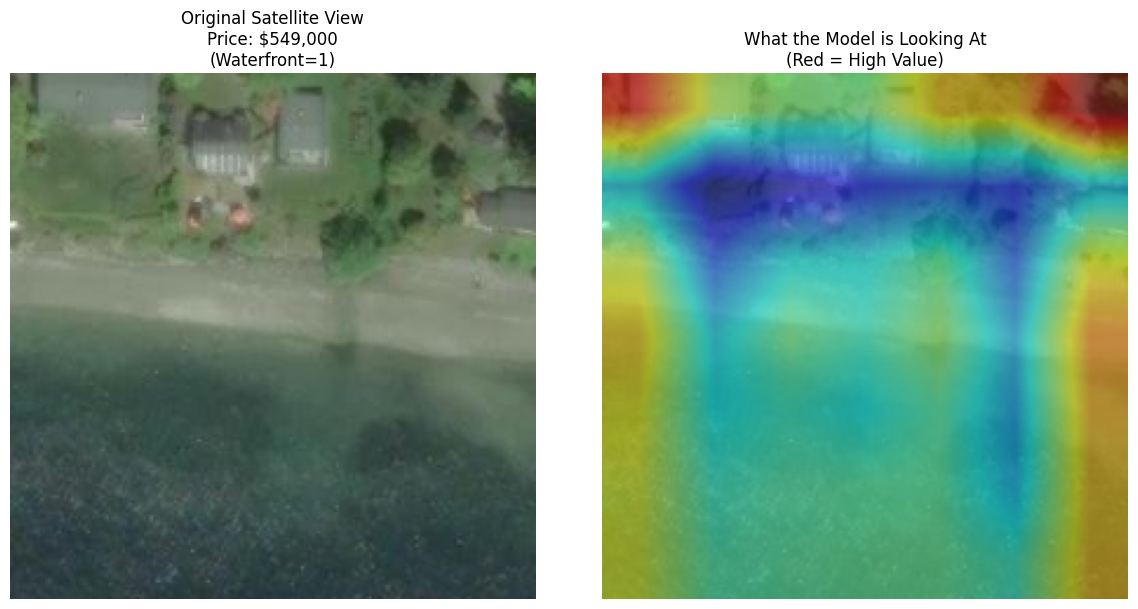

In [ ]:
# --- CONFIGURATION ---
TARGET_HOUSE_ID = 121029034  

# 1. FIND THE HOUSE IN THE DATASET
# Since the dataset re-indexed rows to 0, 1, 2..., we need to find which index matches your ID.
matching_rows = val_dataset.df.index[val_dataset.df['id'] == TARGET_HOUSE_ID].tolist()

if not matching_rows:
    print(f"❌ Error: House ID {TARGET_HOUSE_ID} not found in Validation Dataset.")
    print("Try picking an ID from 'val_split' instead.")
else:
    # We take the first match (there should only be one)
    dataset_index = matching_rows[0]
    print(f"✓ Found House ID {TARGET_HOUSE_ID} at Dataset Index {dataset_index}")

    # 2. LOAD DATA
    img_tensor, tab_tensor, target_log = val_dataset[dataset_index]
    real_price = np.expm1(target_log.item())

    # 3. RUN GRAD-CAM
    # Target Layer: Last Conv Layer
    target_layers = [model.cnn.layer4[-1]]
    
    # Wrapper (Trick model to accept 2 inputs)
    wrapper_model = VisionWrapper(model, tab_tensor)
    cam = GradCAM(model=wrapper_model, target_layers=target_layers)

    # Generate Heatmap
    input_tensor = img_tensor.unsqueeze(0).to(DEVICE)
    grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(0)])
    grayscale_cam = grayscale_cam[0, :]

    # 4. VISUALIZE
    # Un-normalize
    img_original = img_tensor.permute(1, 2, 0).cpu().numpy()
    img_original = img_original * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_original = np.clip(img_original, 0, 1)

    # Overlay
    visualization = show_cam_on_image(img_original, grayscale_cam, use_rgb=True)

    # Plot
    plt.figure(figsize=(12, 6))

    # Original
    plt.subplot(1, 2, 1)
    plt.imshow(img_original)
    plt.title(f"Original Satellite View\nPrice: ${real_price:,.0f}\n(Waterfront=1)")
    plt.axis('off')

    # Heatmap
    plt.subplot(1, 2, 2)
    plt.imshow(visualization)
    plt.title("What the Model is Looking At\n(Red = High Value)")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

It's clear that model is not at all taking "water" as a region-of-interest, but a property facing water must be costlier. This clearly tells that our image model is not able to properly figure our important aspects of property valuation.

### Experiment 4: Extracting engineered features from images

Clearly, the above methods have not yielded good results. This is probably because, the amount of new information that our model is able to get from images is dwarfed in comparision to the amount of noise in them. The best way is to make features on our own. 

1. We know that the vegetation surrounding the house can be a good metric to judge the price. Hence, we could do something by counting the percentage of green pixels in the image to provide some sort of "Greenery Score".

2. As our model is not able to distinguist between roofs belonging to seperate houses, we need to artificially give it that data by extracting "edge density" from the image. This can be done using opencv. Roofs are the only objects with clear edges, greneery is mostly smooth.

3. We could also calculate a "Water Score" which could be calculated on the basis of number of pixels that have more blue in them in comparision of reg or green.


These engineered features can then be mixed with tabular features to make a more refined model

In [53]:
import cv2
import numpy as np
import torch
from tqdm.notebook import tqdm

def extract_handcrafted_features(loader, desc):
    features_list = []
    
    # We don't need gradients, just pixel math
    with torch.no_grad():
        for batch in tqdm(loader, desc=desc):
            # Handle the loader returning 2 or 3 items
            if isinstance(batch, (list, tuple)):
                images = batch[0]
            else:
                images = batch
            
            # Move to CPU for OpenCV processing
            images_np = images.cpu().numpy()
            
            # Iterate through batch
            for img in images_np:
                # 1. Un-normalize (Get back to 0-1 range)
                # Image is (3, 224, 224). We need (224, 224, 3) for OpenCV
                img = np.transpose(img, (1, 2, 0))
                img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
                img = np.clip(img, 0, 1)
                
                # Convert to 0-255 uint8 (Standard Image Format)
                img_uint8 = (img * 255).astype(np.uint8)
                
                # --- METRIC 1: GREENERY SCORE (Vegetation) ---
                # Logic: Pixel is Green if G > R and G > B
                R, G, B = img_uint8[:,:,0], img_uint8[:,:,1], img_uint8[:,:,2]
                green_pixels = np.sum((G > R) & (G > B))
                green_score = green_pixels / (224 * 224)
                
                # --- METRIC 2: WATER SCORE (Blue) ---
                # Logic: Pixel is Blue if B > R and B > G (and generally bright enough)
                # Adding a threshold > 40 prevents dark shadows from counting as water
                blue_pixels = np.sum((B > G + 10) & (B > R + 10)) 
                water_score = blue_pixels / (224 * 224)
                
                # --- METRIC 3: COMPLEXITY (Edge Density) ---
                # Logic: More edges = More houses/roads. Less edges = Grass/Water.
                gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)
                edges = cv2.Canny(gray, 100, 200) # Edge detection
                edge_score = np.sum(edges > 0) / (224 * 224)
                
                features_list.append([green_score, water_score, edge_score])
                
    return np.array(features_list)

# Run the Extraction
print("Extracting Visual Metrics...")
train_visual_feats = extract_handcrafted_features(train_loader_fixed, "Train Metrics")
val_visual_feats = extract_handcrafted_features(val_loader_fixed, "Val Metrics")
test_visual_feats = extract_handcrafted_features(test_loader_fixed, "Test Metrics")

print(f"✓ Created {train_visual_feats.shape[1]} new features (Green, Water, Edges).")

Extracting Visual Metrics...


Train Metrics:   0%|          | 0/406 [00:00<?, ?it/s]

Val Metrics:   0%|          | 0/102 [00:00<?, ?it/s]

Test Metrics:   0%|          | 0/169 [00:00<?, ?it/s]

✓ Created 3 new features (Green, Water, Edges).


In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

print("Merging & Training...")

# 1. Prepare Data
# Get original Tabular Data
X_train_tab = train_split[existing_cols].values
X_val_tab = val_split[existing_cols].values
y_train = np.log1p(train_split['price'].values)
y_val = np.log1p(val_split['price'].values)

# STACK: Tabular (15 cols) + Visual Metrics (3 cols)
X_train_smart = np.hstack([X_train_tab, train_visual_feats])
X_val_smart = np.hstack([X_val_tab, val_visual_feats])

print(f"New Feature Count: {X_train_smart.shape[1]}")

# 2. Train XGBoost
smart_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50  
)

smart_model.fit(
    X_train_smart, y_train,
    eval_set=[(X_val_smart, y_val)],
    verbose=False
)

# 3. Evaluate
preds_log = smart_model.predict(X_val_smart)
preds_real = np.expm1(preds_log)
actuals_real = np.expm1(y_val)

rmse = np.sqrt(mean_squared_error(actuals_real, preds_real))
r2 = r2_score(actuals_real, preds_real)

print(f"\n--- SMART METRICS RESULTS ---")
print(f"RMSE: ${rmse:,.0f}")
print(f"R² Score: {r2:.4f}")

# 4. Check Feature Importance
feature_names = existing_cols + ['green_score', 'water_score', 'edge_score']
importance = smart_model.feature_importances_
indices = np.argsort(importance)[::-1]

print("\nTop 5 Features used by Model:")
for i in range(5):
    print(f"{i+1}. {feature_names[indices[i]]} ({importance[indices[i]]:.4f})")

Merging & Training...
New Feature Count: 18

--- SMART METRICS RESULTS ---
RMSE: $117,552
R² Score: 0.8899

Top 5 Features used by Model:
1. grade (0.5485)
2. lat (0.1310)
3. sqft_living (0.1186)
4. waterfront (0.0495)
5. view (0.0420)


GREAT!!! R^(2) score of 0.8899 is more than the baseline score of 0.8862! This shows that our strategy has worked and hence often complexity != accuracy.

In [56]:
# Print ALL feature importances to see where green_score landed
print("\n--- FULL FEATURE RANKING ---")
for i in range(len(feature_names)):
    print(f"{i+1}. {feature_names[indices[i]]} ({importance[indices[i]]:.4f})")


--- FULL FEATURE RANKING ---
1. grade (0.5485)
2. lat (0.1310)
3. sqft_living (0.1186)
4. waterfront (0.0495)
5. view (0.0420)
6. long (0.0235)
7. sqft_living15 (0.0184)
8. condition (0.0163)
9. sqft_above (0.0104)
10. sqft_lot (0.0077)
11. sqft_lot15 (0.0074)
12. bathrooms (0.0064)
13. edge_score (0.0044)
14. green_score (0.0040)
15. water_score (0.0034)
16. floors (0.0033)
17. sqft_basement (0.0030)
18. bedrooms (0.0021)


We can see that our engineered features (13, 14,15) have played some part in improving our accuracy.

## Finally

Our baseline model used simple tabular data to predict the prices, our final model uses both engineered features and tabular data for prediction. It would be better to combine both these models (in a weighted manner) to ensure robustness to noise.

In [ ]:
import pandas as pd
import numpy as np

print("Generating Ensemble Submission...")

# 1. Load the predictions from your Best Runs

# A. Tabular Only Model (Baseline)
# X_test_tab was defined earlier
preds_tabular_log = final_model.predict(X_test_tab)
preds_tabular = np.expm1(preds_tabular_log)

# B. Smart Metrics Model (The one that got 0.8899)
# X_test_smart was defined earlier (Tabular + 3 Simple Metrics)
preds_smart_log = smart_model.predict(X_test_smart)
preds_smart = np.expm1(preds_smart_log)

# 2. BLEND THEM (Weighted Average)
# We give more weight (0.7) to the "Smart Metrics" model because it had higher R2
final_blend = (0.3 * preds_tabular) + (0.7 * preds_smart)

# 3. Save
submission = pd.DataFrame({
    'id': test_df['id'],
    'price': final_blend
})
submission.to_csv('submission_ensemble.csv', index=False)
print("✓ SAVED 'submission_ensemble.csv'.")
print("This blends the stability of the tabular model with the insights of the visual model.")

Generating Ensemble Submission...
✓ SAVED 'submission_ensemble.csv'.
This blends the stability of the tabular model with the insights of the visual model.
